In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np


groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = [f"{group}_{t}" for group in groups for t in range(7)]
columns.append("target")

df = pd.read_csv(
    "Twitter.data",
    header=None,
    names=columns
)

print(df.shape)
#df.head(20)

df["target_log"] = np.log1p(df["target"])

(583250, 78)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1. Ознаки і target
X = df.drop(columns=["target", "target_log"])
y = df["target_log"]

# 2. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# 4. Навчання
xgb_model.fit(X_train, y_train)

# 5. Прогноз
y_pred_log = xgb_model.predict(X_test)

# 6. Метрики
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5
r2_log = r2_score(y_test, y_pred_log)

print("XGBoost Regression on log(target)")
print(f"MAE  (log scale): {mae_log:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"R²   (log scale): {r2_log:.4f}")

XGBoost Regression on log(target)
MAE  (log scale): 0.3347
RMSE (log scale): 0.4692
R²   (log scale): 0.9455


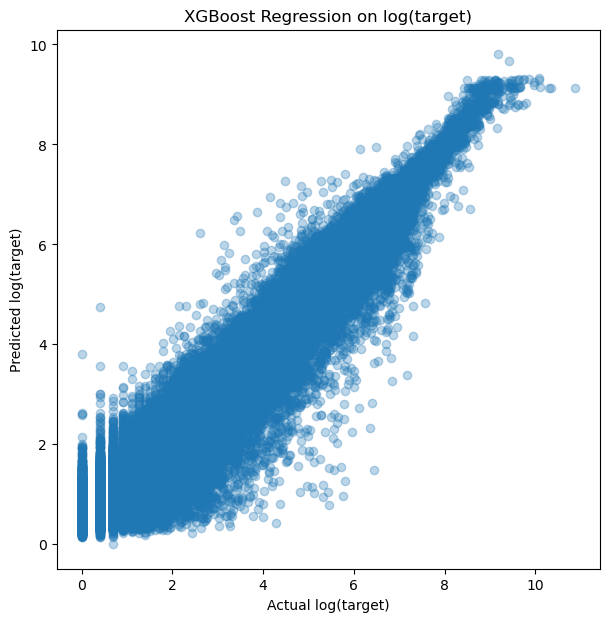

In [4]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_log, alpha=0.3)
plt.xlabel("Actual log(target)")
plt.ylabel("Predicted log(target)")
plt.title("XGBoost Regression on log(target)")
plt.show()

   base_feature  importance
9           NAD    0.760462
10          NCD    0.181124
8           NAC    0.035667
7            NA    0.006995
6            CS    0.005041


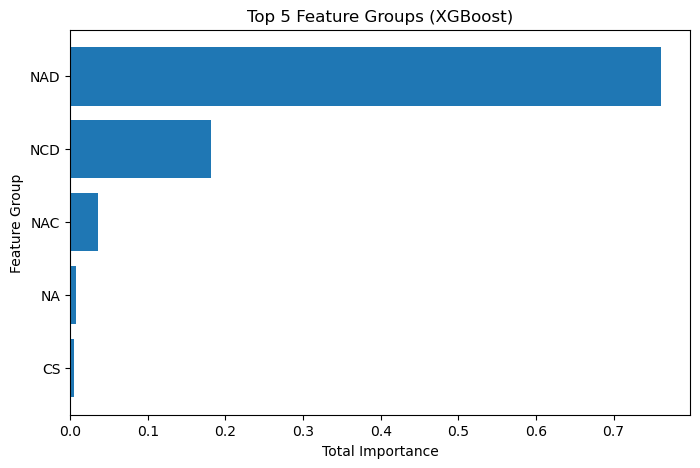

In [9]:
importances = xgb_model.feature_importances_
feature_names = X.columns 


feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_imp["base_feature"] = feat_imp["feature"].apply(lambda x: x.rsplit("_", 1)[0])

grouped_importance = ( feat_imp.groupby("base_feature")["importance"].sum().reset_index())
grouped_importance = grouped_importance.sort_values(by="importance",ascending=False)


top_grouped = grouped_importance.head(5)

print(top_grouped)

plt.figure(figsize=(8, 5))
plt.barh(top_grouped["base_feature"], top_grouped["importance"])
plt.gca().invert_yaxis()

plt.title("Top 5 Feature Groups (XGBoost)")
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")

plt.show()